# Uczenie głębokie 


## laboratorium: Regularyzacja w keras

Najważniejsze koncepcje :
-   Przeuczenie
-   testowanie i walidacja

# Zadania

## Zadanie 1

Wyznaczyć obciążenie i wariancję dla regresji wielomianowej

Zabdać dopasowanie modelu w przypadku gdy:

- szum jest duże (~4) i mały (~1)
- Model jest mocno (~10) i słabo elastyczny(1)
- Mamy duże (~1000) i mało (~20) obserwacji

**Elastyczność mierzymy stopniem wielomianu**

Wykorzystać kod poniżej

In [1]:
import numpy as np
import pandas as pd

def mean_squared_error(y, y_hat):
    return np.square(y-y_hat).mean()

class PolyModel:
    n:int

    def __init__(self, n) -> None:
        self.n=n
        self.p = None

    def fit(self, x,y):
        self.p = np.polyfit(x,y, deg=self.n)
        return self

    def predict(self, x):
        return np.polyval(self.p, x)

def experiment(truefun, modelfun, predictfun=None, noise=0.1, n=50, seed=None, plot=True, point=False):
    """
    Simulates an experiment and calculates the mean squared error (MSE).

    Args:
        truefun (function): The true function of the experiment.
        modelfun (function): The function to fit the model to the data.
        predictfun (function, optional): The function to make predictions using the model.
            Defaults to None, which assumes the model object has a predict method.
        noise (float, optional): The standard deviation of the added noise. Defaults to 0.1.
        n (int, optional): The number of data points to generate. Defaults to 50.
        seed (int, optional): The random seed for reproducibility. Defaults to None.
        plot (bool, optional): Whether to plot the data and fitted model. Defaults to True.

    Returns:
        float: The mean squared error (MSE) between the true and predicted values.
    """

    if seed is not None:
        np.random.seed(seed)

    # Generate data
    exam = pd.DataFrame({
        #"x": np.random.uniform(-3, 1.7, size=n)
        "x": np.linspace(-3, 1.7, num=n)
    })
    exam["fx"] = truefun(exam["x"])
    exam["y"] = exam["fx"] + np.random.normal(scale=noise, size=n)

    # Fit the model
    fit = modelfun(exam)

    # Generate new data for predictions
    newdata = pd.DataFrame({
        "x": (np.arange(0, 0.02, 0.01) if point else np.arange(-3, 1.7, 0.01))
        #"x": np.arange(0, 0.02, 0.01)
    })

    # Predict using the fitted model (or custom predict function)
    if predictfun is None:
        newdata["yhat"] = fit.predict(newdata)
    else:
        newdata["yhat"] = predictfun(fit, newdata)

    # Calculate true values for new data
    newdata["ytrue"] = truefun(newdata["x"])


    #mse = mean_squared_error(newdata["ytrue"], newdata["yhat"])
    err = newdata["ytrue"]- newdata["yhat"]

    if plot:
        import matplotlib.pyplot as plt

        # Create the plot
        plt.figure(figsize=(8, 6))
        plt.scatter(exam["x"], exam["y"], color='green', s=4, label='Data')
        plt.plot(newdata["x"], newdata["yhat"], color='blue', label='Fitted Model')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Experiment')
        plt.legend()
        plt.grid(True)
        plt.show()

    return err




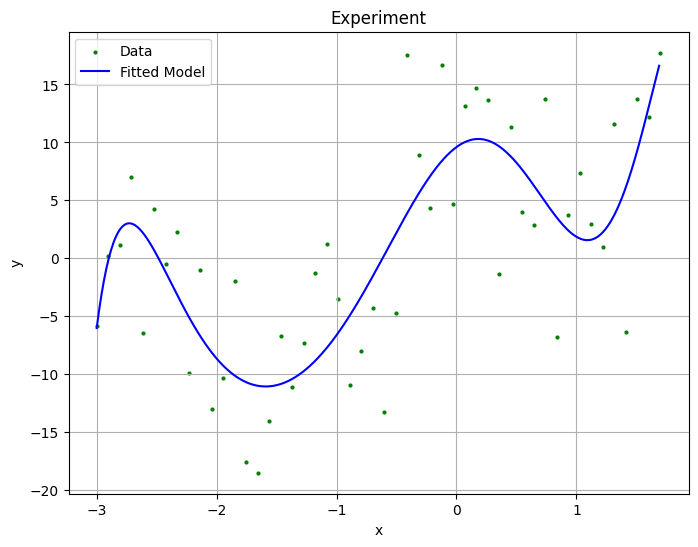

In [2]:
experiment(truefun = lambda x: x**5+3.5*x**4-2.5*x**3-12.5*x**2+3.5*x+9,
           modelfun = lambda df: PolyModel(8).fit(df['x'], df['y']),
           noise=5.5/1,plot = True );

## Zadanie 2

Przeuczyć a następnie regularyzować neuronowy model funkcji schodkowej.

Kroki do wykonania:

1. Dodać zbiór testowy
2. Rozbudować sieć aproksymującą (dodać neuronów i warstw)
3. Porównać funkcje kosztu dla treningu i testu
4. Dodać regularyzację, zbadać 
   1. Dropout
   2. l1/l2 na warstwach
5. Sprawdzić efekt połaczenia rezydulanego i normalizacji


In [3]:
import numpy as np

def staircase_function(x):
    p=np.poly(-np.array([-1,-0.5,0.5,1]))
    smooth = np.polyval(p,x)/0.2
    return np.ceil(smooth),smooth

<Axes: >

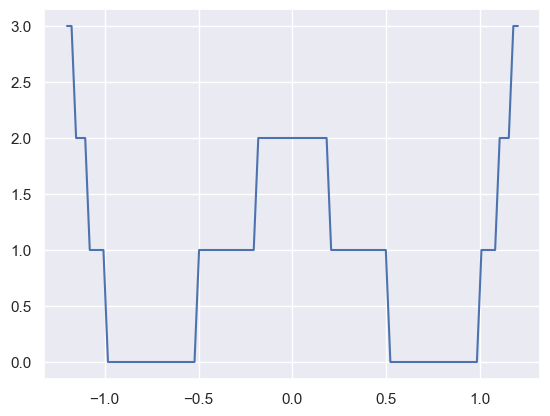

In [4]:
import seaborn as sns
sns.set_theme()

x = np.linspace(-1.2,1.2,100)
y,ysmooth = staircase_function(x)

sns.lineplot(x=x,y=y)

In [5]:
xtrain = np.random.uniform(low=x[0],high=x[-1],size=(128,1))
ytrain,_ = staircase_function(xtrain)

In [ ]:
# TODO rozwiązanie